This 'multi_voigt' code uses the foundation of 'xicsrt_voigt' and extends the functions to be used on multiple lines.

We cannot directly use those functions from 'xicsrt_voigt' because it is based on the assumption that there is only one Voigt profile, which is centered at zero. We rewrite the functions to be compatible with multiple Voigt profiles/lines.

In [1]:
import numpy as np
from scipy.special import wofz

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")

def voigt(x, intensity=None, location=None, sigma=None, gamma=None):
    """
    Evaluates one Voigt profile. 

    Parameters:
        x : wavelength grid
        intensity : strength/area scaling of the line
        location : center of the wavelength line
        sigma : Gaussian width
        gamma : Lorentzian width

    Returns: 
        y: intensity of this one Voigt line at every x value
    """
    
    z = (x - location + 1j*gamma)/np.sqrt(2)/sigma
    y = wofz(z).real/np.sqrt(2*np.pi)/sigma * intensity
    
    return y



def multi_voigt(x, line_locations, line_intensities, sigmas, gammas):
    """
    Evaluates the summed spectrum from multiple Voigt profiles. 

    Parameters: 
        x : wavelength grid
        line_locations : center wavelength of each spectral line
        line_intensities : intensity (area) of each spectral line
        sigmas : Gaussian width of each spectral line
        gammas : Lorentzian width of each spectral line

    Returns: 
        y : sum of all Voigt profiles evaluated on the wavelength gird
    
    """

    x = np.asarray(x)
    y = np.zeros_like(x, dtype = float)

    for location, intensity, sigma, gamma, in zip(
            line_locations, 
            line_intensities, 
            sigmas, 
            gammas):
        y += voigt(
            x, 
            intensity = intensity, 
            location = location, 
            sigma = sigma, 
            gamma = gamma,
        )

    return y



def multi_voigt_cdf_tab(line_locations, line_intensities, sigmas, gammas, gridsize=None, cutoff=None):
    """
    Numerical CDF table for a spectrum made from multiple Voight profiles.
    This follows the structure of 'voigt_cdf_tab()': 
        1. Create wavelength-bin bounds.
        2. Evaluate the spectral distribution on the grid.
        3. Multiply the bin width to approximate the area.
        4. Cumulatively sum those areas to create the CDF.
        5. Normalize the CDF so that it ends at 1.
    This function builds one CDF for the sum of many Voigt lines.
    """

    if cutoff is None: 
        cutoff = 1e-4

    # The 'voigt_cdf_tab()' function scheme worked will with a minimum of 100 points.
    # With that function it was possible to go as low as 50 points, but accuracy was not great.
    gridsize_min = 100

    # Converts inputs to Numpy arrays 
    line_locations = np.asarray(line_locations)
    line_intensities = np.asarray(line_intensities)
    sigmas = np.asarray(sigmas)
    gammas = np.asarray(gammas)

    # Using the largest sigma and gamma value for determining lorentz and gauss cutoffs
    sigma_max = np.max(sigmas)
    gamma_max = np.max(gammas)

    # Using smallest sigma and gamma value for determining 'min_spacing' and 'value'
    sigma_min = np.min(sigmas)
    gamma_min = np.min(gammas)
    
    fraction = 0.5

    # Gaussian and Lorentzian half-width estimates copied from original function
    gauss_hwfm = np.sqrt(2.0 * np.log(1.0 / fraction)) * sigma_min
    lorentz_hwfm = gamma_min * np.sqrt(1.0 / fraction - 1.0)
    
    # Estimate the half-width of the narrowest Voigt profile
    hwfm_min = np.sqrt(gauss_hwfm**2 + lorentz_hwfm**2)
    
    # 'min_spacing' depends on the smallest sigma and gamma.
    min_spacing = hwfm_min / 5.0

    # Determine a cutoff value using max sigma and gamma.
    lorentz_cutoff = gamma_max * np.sqrt(1.0 / cutoff - 1.0)
    gauss_cutoff = np.sqrt(-1 * sigma_max**2 * 2 * np.log(cutoff * sigma_max * np.sqrt(2 * np.pi)))
    value_cutoff = max(lorentz_cutoff, gauss_cutoff)

    # For multiple lines, we make one grid that covers all line centers.
    # Adds enough room on both sides for the line tails.
    wave_min = np.min(line_locations) - value_cutoff
    wave_max = np.max(line_locations) + value_cutoff
    
    # Instead of using a fixed grid size, we use 'min_spacing' to compute it 
    if gridsize is None: 
        domain_width = wave_max - wave_min
        gridsize = max(gridsize_min, int(np.ceil(domain_width / min_spacing)))
        # adding a sanity check to see if the computed gridsize is too large
        if gridsize > 1_000_000:
            print(f"Warning: Computed gridsize ({gridsize}) is very large.")
            
    bounds = np.linspace(wave_min, wave_max, gridsize + 1)

    # 'cdf_x' is the center of each wavelength bin
    cdf_x = (bounds[:-1] + bounds[1:]) / 2

    # Evaluating the summed multiline Voigt spectrum
    pdf = np.zeros_like(cdf_x)
    pdf = multi_voigt(cdf_x, line_locations, line_intensities, sigmas, gammas,)

    # Approximating the area in each wavelength bin.
    # Matches original function for rectangle-style CDF construction.
    pdf_dx = pdf * (bounds[1:] - bounds[:-1])

    # Cumulative sum of bin areas gives the CDF
    cdf = np.cumsum(pdf_dx)
    
    # Normalizing the CDF so that the total accumulated area equals 1.
    cdf = cdf / cdf[-1]

    if (np.max(cdf) < 0.99):
        raise Exception('Multiline Voigt CDF calculation domain too small.')
    
    # returns all three arrays: 
    # (1) bounds[1:] : righthand boundary of each wavelength bin
    # (2) cdf : cumulative distribution function
    # (3) pdf : summed multiline Voigt spectrum
    return bounds[1:], cdf, pdf


def multi_voigt_random(line_locations, line_intensities, sigmas, gammas, size, gridsize=None, cutoff=None):
    """
    Draw random wavelength samples from a multiline Voigt spectrum.

    Parameters:
        line_locations : center wavelength of each Voigt line
        line_intensities : intensity of each Voigt line
        sigmas : Gaussian width of each Voigt line
        gammas : Lorentzian width of each Voigt line
        size : number of random wavelength samples to generate
        gridsize : number of wavelength grid points used to build the CDF
        cutoff : relative intensity cutoff used to determine the wavelength domain of CDF

    Returns:
        random_x : randomly sampled wavelengths drawn from the multiline Voigt spectrum

    Notes: 
        Is linear interpolation sufficient for this?
        Should we use quadratic interpolation instead?
        Keep in mind that linear interpolation is faster, but quadratic may behave better/worse and slower
    """

    cdf_x, cdf, spectrum = multi_voigt_cdf_tab(
        line_locations,
        line_intensities,
        sigmas,
        gammas,
        gridsize=gridsize,
        cutoff=cutoff,
    )

    # Generate uniformly distributed random probability values
    random_y = np.random.uniform(np.min(cdf), np.max(cdf), size)

    # uses the inverse CDF to convert the probabilities into wavelengths
    random_x = np.interp(random_y, cdf, cdf_x)

    return random_x

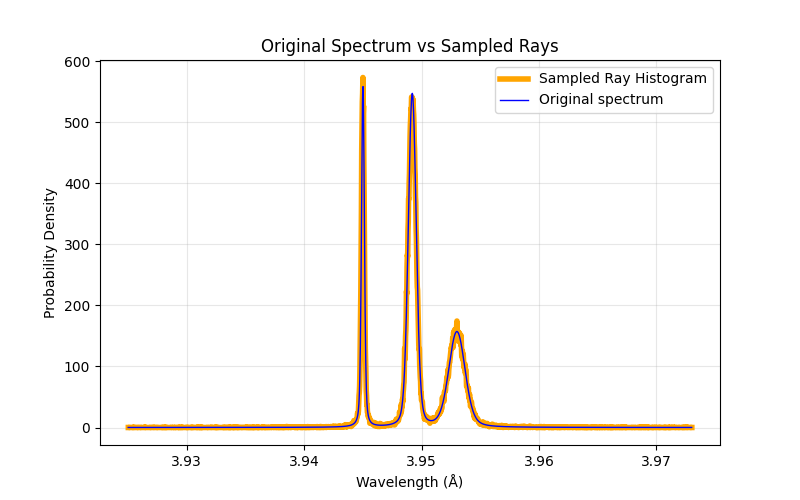

In [2]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt

# Three test Voigt lines
line_locations = np.array([3.945, 3.9492, 3.953])
line_intensities = np.array([0.4, 1.0, 0.6])

sigmas = np.array([0.00010, 0.00030, 0.00060])
gammas = np.array([0.00005, 0.00008, 0.00020])

# ------------------------------------------------------------
# Build CDF and spectrum
# ------------------------------------------------------------
cdf_x, cdf, spectrum = multi_voigt_cdf_tab(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
)
# print(len(cdf_x))

# ------------------------------------------------------------
# Sample ray wavelengths
# ------------------------------------------------------------
sampled_wavelengths = multi_voigt_random(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
    size=100000,
)

# Required step is normalizing the spectrum if 'plt.hist(..., density=True,...)'
spectrum_pdf = spectrum / np.trapezoid(spectrum, cdf_x)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

"""
# Histogram of sampled ray wavelengths
plt.hist(
    sampled_wavelengths,
    bins=300,
    density=True,
    histtype='bar',
    edgecolor='orange',
    linewidth=0.3,
    alpha=0.5,
    color='orange',
    label='Sampled ray histogram',
)
"""

# Calculating the histogram and plotting as line
hist_counts, hist_edges = np.histogram(
    sampled_wavelengths, 
    bins=np.append(cdf_x, cdf_x[-1] + (cdf_x[1] - cdf_x[0])), 
    density = True,
)
hist_centers = 0.5 * (hist_edges[:-1] + hist_edges[1:])
plt.plot(
    hist_centers, 
    hist_counts, 
    color = 'orange',
    linewidth = 4, 
    label = 'Sampled Ray Histogram',
)


# Original multi-line spectrum
plt.plot(
    cdf_x,
    spectrum_pdf,
    color='blue',
    linewidth=1,
    # marker='o',
    label='Original spectrum',
)

plt.xlabel("Wavelength (Å)")
plt.ylabel("Probability Density")
plt.title("Original Spectrum vs Sampled Rays")

plt.grid(alpha=0.3)
plt.legend()

plt.show()

INFO:xicsrt.xicsrt_raytrace:Starting run: 1 of 1
INFO:xicsrt.xicsrt_raytrace:Seeding np.random with None


Using sampled wavelength: 3.9458040364442932


INFO:xicsrt.xicsrt_raytrace:Starting iteration: 1 of 1
C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\DESC\desc\vmec.py:93: UserWarning: VMEC output appears to be from version 8.48 while DESC is only designed for compatibility with VMEC version 9. Some data may not be loaded correctly.
  warnings.warn(
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00_0000.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_crystal__00.tif
INFO:xicsrt.xicsrt_io:Saved image: C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_detector__00.tif



Rays Generated: 4.514e+05
Rays Detected:  1.210e+02
Efficiency:     2.680e-04 ± 2.4e-05 (0.02680%)



INFO:xicsrt.util.profiler:name                      total           single          calls 
INFO:xicsrt.util.profiler:raytrace                  0:01:03.578610  0:01:03.578610       1
INFO:xicsrt.util.profiler:raytrace_single           0:01:03.551400  0:01:03.551400       1
INFO:xicsrt.util.profiler:_raytrace_iter            0:00:59.779650  0:00:59.779650       1
INFO:xicsrt.util.profiler:Bundle Input Generation   0:00:38.177123  0:00:38.177123       1
INFO:xicsrt.util.profiler:Fluxspace from Realspace  0:00:38.177123  0:00:38.177123       1
INFO:xicsrt.util.profiler:Ray Bundle Generation     0:00:02.541186  0:00:00.000779    3263
INFO:xicsrt.util.profiler:generate_rays             0:00:02.064214  0:00:00.000633    3263
INFO:xicsrt.util.profiler:generate_wavelength       0:00:01.196614  0:00:00.000367    3263
INFO:xicsrt.util.profiler:generate_direction        0:00:00.642707  0:00:00.000197    3263
INFO:xicsrt.util.profiler:Dispatcher: raytrace      0:00:00.304817  0:00:00.304817       1

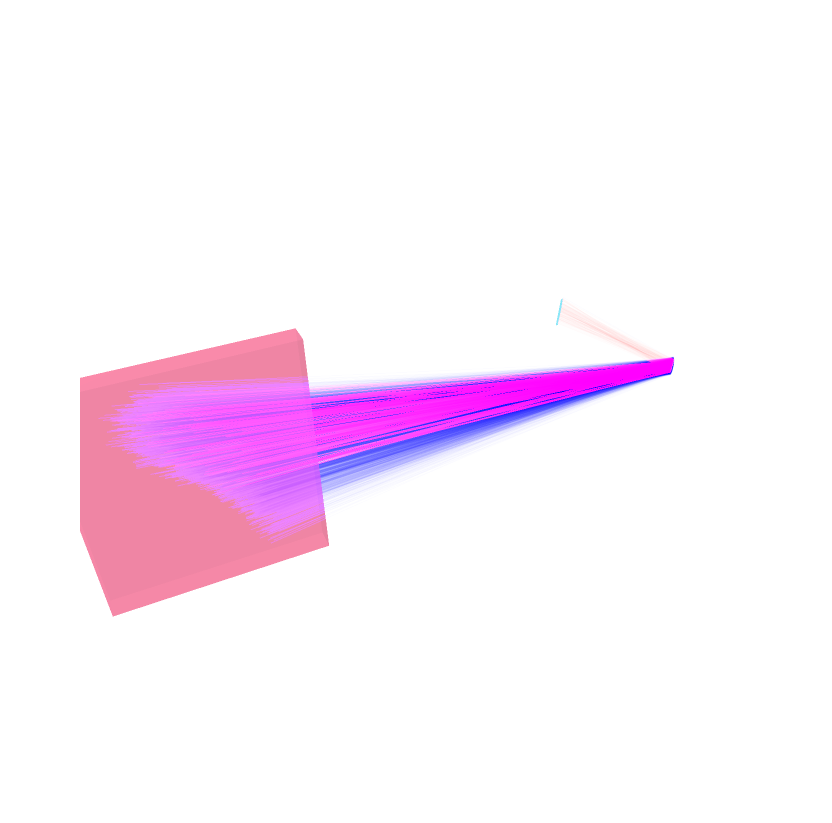

In [4]:
%matplotlib widget
import numpy as np
from collections import OrderedDict
import os

# Setup the module path.
import sys
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_contrib")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\xicsrt_analysis")
sys.path.append(r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\mirfusion_library")

## Start Logging
import logging
logging.basicConfig(level=logging.DEBUG)
logging.getLogger('matplotlib').setLevel(logging.WARNING)
logging.getLogger('PIL').setLevel(logging.WARNING)
logging.getLogger('h5py').setLevel(logging.WARNING)
logging.getLogger('jax').setLevel(logging.WARNING)

from mirutil import mirprint

# Import xicsrt modules
import xicsrt
from xicsrt.util import profiler

from w7x_npablant import xicsrt_w7x_npablant

# import the multilin Voigt function here
# change this import path to wherever the function is placed
# from xicsrt.tools.xicsrt_voigt import multiline_voigt_random

config = xicsrt_w7x_npablant.get_config()
config = xicsrt_w7x_npablant.initialize(config)

config['general']['comment'] = """
W7-X run without velocity profile profile.
Based on Op1.2b geometry calibration.

Simple polynomial profiles for emissivity, temperature and velocity.

Full crystal W7-X Ar16+ raytracing simulation with realistic W7-X plasma geometry.
"""

config['general']['number_of_runs'] = 1
config['general']['number_of_iter'] = 1
config['general']['save_images'] = True
config['general']['make_directories'] = True
config['general']['keep_history'] = True

config['general']['output_path'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026"
config['general']['output_suffix'] = '_00'

config['sources']['plasma']['wout_file'] = r"C:\Users\leila\Documents\Visual Studio\pppl_xics_2026\wout.nc"
config['sources']['plasma']['enable_velocity'] = False
config['sources']['plasma']['enable_flux_compression'] = False
config['sources']['plasma']['time_resolution'] = 1e-3
config['sources']['plasma']['spread'] = np.radians(1.0)
config['sources']['plasma']['xsize'] = 0.15

# ------------------------------------------------------------
# Multi-Voigt sampled wavelength test
# ------------------------------------------------------------

line_locations = np.array([3.9492, 3.9660, 3.9695, 3.9944])
line_intensities = np.array([1.0, 0.5, 0.5, 0.3])
sigmas = np.array([0.002, 0.002, 0.002, 0.002])
gammas = np.array([0.001, 0.001, 0.001, 0.001])

sampled_wavelengths = multi_voigt_random(
    line_locations,
    line_intensities,
    sigmas,
    gammas,
    size=1,
    gridsize=None,
    cutoff=1e-4,
)

config['sources']['plasma']['wavelength'] = sampled_wavelengths[0]

print("Using sampled wavelength:", config['sources']['plasma']['wavelength'])

# ------------------------------------------------------------
# Raytrace
# ------------------------------------------------------------

profiler.resetProfiler()
profiler.startProfiler()

result = xicsrt.raytrace(config)
    
profiler.stopProfiler()
profiler.report()

import xicsrt.visual.xicsrt_3d__plotly as xicsrt_3d

fig = xicsrt_3d.figure()
# xicsrt_3d.add_fluxsurfaces(result['config'], range_n=(0, np.pi*2))
xicsrt_3d.add_rays(result)
xicsrt_3d.add_optics(result['config'])
xicsrt_3d.add_sources(result['config'])

fig.update_layout(
    autosize=False,
    width=1000,
    height=800,
)

xicsrt_3d.show()